# Perfiles Hernquist con retroacción del halo: resultados de results/HRNQ_380Mpc_1200_results

Se grafican las iteraciones y el resultado final de `HRNQ_380Mpc_1200.py`, individualmente y en conjunto. Se muestran la pendiente local, los cambios relativos entre iteraciones consecutivas hasta la convergencia y comparaciones con perfiles analíticos de $\gamma=1$. Los radios están en pc y las densidades en $M_\odot/\mathrm{pc}^3$.

**Procedencia:** esta ejecución contiene 1200 radios y registra $M_{\rm halo}=6.06\times10^{11}M_\odot$, $a=40$ kpc y $M_{\rm BH}=2.6\times10^6M_\odot$. Los parámetros del Hernquist inicial y de la normalización interior de las leyes de potencia se leen de `config_json` en los NPZ.

Los ejes de los perfiles muestran $\log_{10}(r/R_S)$ y $\log_{10}[\rho^\prime/(M_\odot\,\mathrm{pc}^{-3})]$, donde $R_S$ es el radio de Schwarzschild.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

# El notebook vive en la raíz del repositorio; también funciona si el kernel
# se inicia desde una subcarpeta del proyecto.
ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / 'results' / 'HRNQ_380Mpc_1200_results').is_dir() and (p / 'src' / 'dm_spikes').is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('No se encontró la raíz del repositorio con results/HRNQ_380Mpc_1200_results.')
sys.path.insert(0, str(ROOT / 'src'))

from dm_spikes.density_models import hernquist, power_law
from dm_spikes.final_profile import schwarzschild_radius
from dm_spikes.power_law_profile import D, rho_D, cusp_profile, gamma_spike, spike_radius

results_dir = ROOT / 'results' / 'HRNQ_380Mpc_1200_results'
result_files = sorted(results_dir.glob('*.npz'))
if not result_files:
    raise FileNotFoundError(f'No hay archivos NPZ en {results_dir}')

records = []
for path in result_files:
    with np.load(path, allow_pickle=False) as data:
        radii = np.asarray(data['radii'], dtype=float).copy()
        density = np.asarray(data['rho_prime'], dtype=float).copy()
        config = json.loads(data['config_json'].item())
        is_final = 'iterations' in data.files
        iteration = int(data['iterations' if is_final else 'iteration'].item())
        converged = bool(data['converged'].item())
    if radii.ndim != 1 or radii.shape != density.shape:
        raise ValueError(f'Malla y densidad incompatibles: {path.name}')
    if not (np.all(np.isfinite(radii)) and np.all(np.isfinite(density))
            and np.all(radii > 0) and np.all(density > 0)):
        raise ValueError(f'Los ejes logarítmicos requieren datos finitos y positivos: {path.name}')
    label = f'Final ({iteration} iteraciones)' if is_final else f'Iteración {iteration:03d}'
    records.append(dict(path=path, radii=radii, density=density, config=config,
                        is_final=is_final, iteration=iteration,
                        converged=converged, label=label))
records.sort(key=lambda rec: (rec['is_final'], rec['iteration'], rec['path'].name))

reference = next(rec for rec in records if rec['is_final'])['config']
R_S = schwarzschild_radius(reference['M_bh'], G=reference['G'], clight=reference['clight'])

# Mismo limite visible que el grafico de densidades de perfiles_analiticos.ipynb:
# 4.0001 R_S hasta el mayor R_sp de gamma=0.01,...,1.99, con margen del 5 %.
reference_gammas = np.arange(0.01, 2.00, 0.01)
reference_rsp = spike_radius(reference['M_bh'], reference_gammas,
                             rho_D(reference_gammas), D)
reference_x_start = np.log10(4.0001)
reference_x_end = np.log10(np.max(reference_rsp) / R_S)
reference_x_left = reference_x_start - 0.05 * (reference_x_end - reference_x_start)

r_min = min(rec['radii'].min() for rec in records)
r_max = max(rec['radii'].max() for rec in records)
rho_min = min(rec['density'].min() for rec in records)
rho_max = max(rec['density'].max() for rec in records)

def format_axes(ax, title):
    ax.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
           ylim=(np.log10(rho_min / 2), np.log10(rho_max * 2)),
           title=title,
           xlabel=r'$\log_{10}(r/R_S)$',
           ylabel=r'$\log_{10}[\rho^\prime(r)/(M_\odot\,\mathrm{pc}^{-3})]$')
    ax.grid(True, alpha=0.25)

print(f'{len(records)} resultados cargados desde {results_dir}')
print(', '.join(rec['path'].name for rec in records))

def add_profile_zoom(ax):
    """Amplía en un recuadro las mismas curvas y estilos del gráfico principal."""
    x_left, x_right = 7.9, 8.0
    zoom_ax = ax.inset_axes((0.075, 0.08, 0.43, 0.38))
    visible_y = []
    for line in ax.get_lines():
        x = np.asarray(line.get_xdata(), dtype=float)
        y = np.asarray(line.get_ydata(), dtype=float)
        selected = (x >= x_left) & (x <= x_right) & np.isfinite(x) & np.isfinite(y)
        if np.count_nonzero(selected) < 2:
            continue
        visible_y.append(y[selected])
        zoom_ax.plot(x, y, color=line.get_color(), linestyle=line.get_linestyle(),
                     linewidth=line.get_linewidth(), alpha=line.get_alpha(),
                     marker=line.get_marker(), markersize=line.get_markersize(),
                     markevery=line.get_markevery(), zorder=line.get_zorder())
    if not visible_y:
        raise ValueError('No hay puntos en la región elegida para el zoom.')
    y_zoom = np.concatenate(visible_y)
    y_padding = 0.07 * (y_zoom.max() - y_zoom.min())
    zoom_ax.set(xlim=(x_left, x_right),
                ylim=(y_zoom.min() - y_padding, y_zoom.max() + y_padding))
    zoom_ax.set_xticks([7.9, 7.95, 8.0])
    zoom_ax.tick_params(labelsize=8)
    zoom_ax.grid(True, alpha=0.25)
    zoom_ax.set_facecolor('white')
    zoom_ax.set_zorder(20)
    ax.indicate_inset_zoom(zoom_ax, edgecolor='0.35')
    return zoom_ax

9 resultados cargados desde C:\Users\luisa\Documents\Repo GitHub\DM-spikes\results\HRNQ_380Mpc_1200_results
hernquist_380mpc_20261008_230132_iter_001.npz, hernquist_380mpc_20261008_230132_iter_002.npz, hernquist_380mpc_20261008_230132_iter_003.npz, hernquist_380mpc_20261008_230132_iter_004.npz, hernquist_380mpc_20261008_230132_iter_005.npz, hernquist_380mpc_20261008_230132_iter_006.npz, hernquist_380mpc_20261008_230132_iter_007.npz, hernquist_380mpc_20261008_230132_iter_008.npz, hernquist_380mpc_20261008_230132_final.npz


## Cada resultado por separado

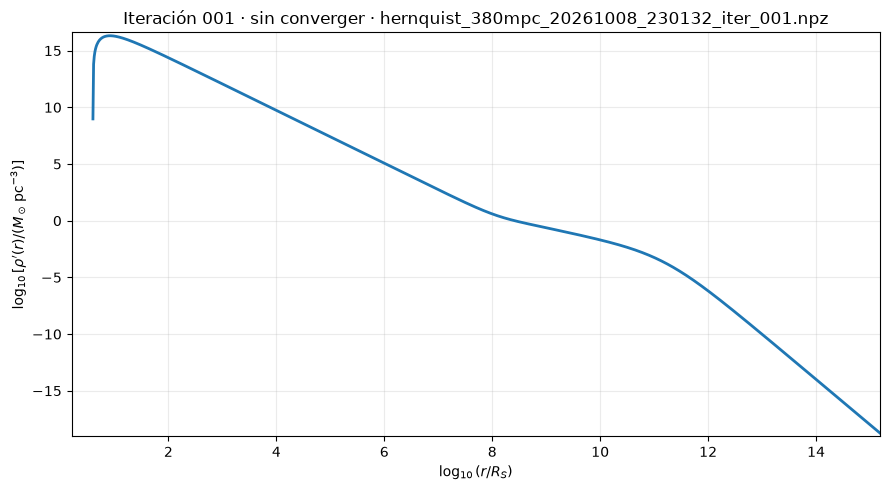

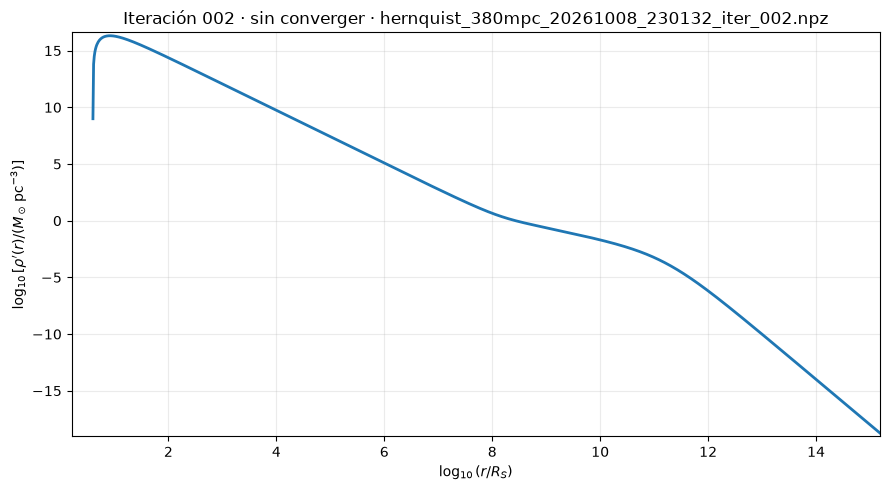

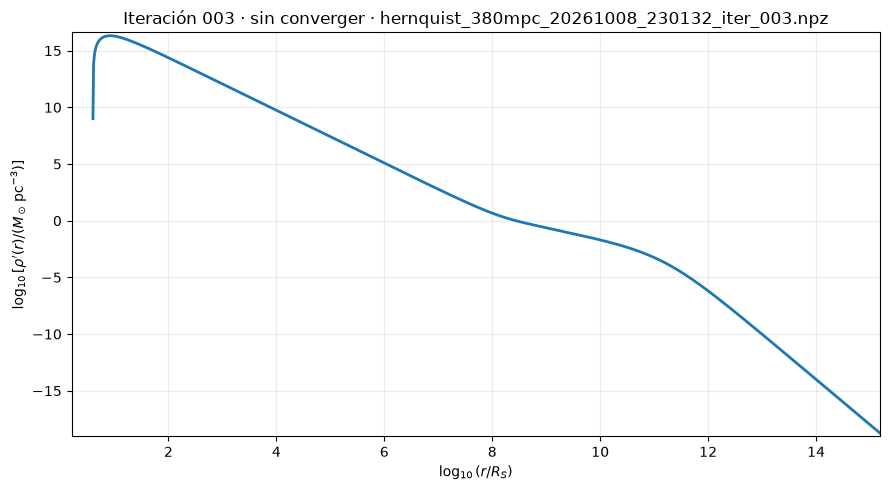

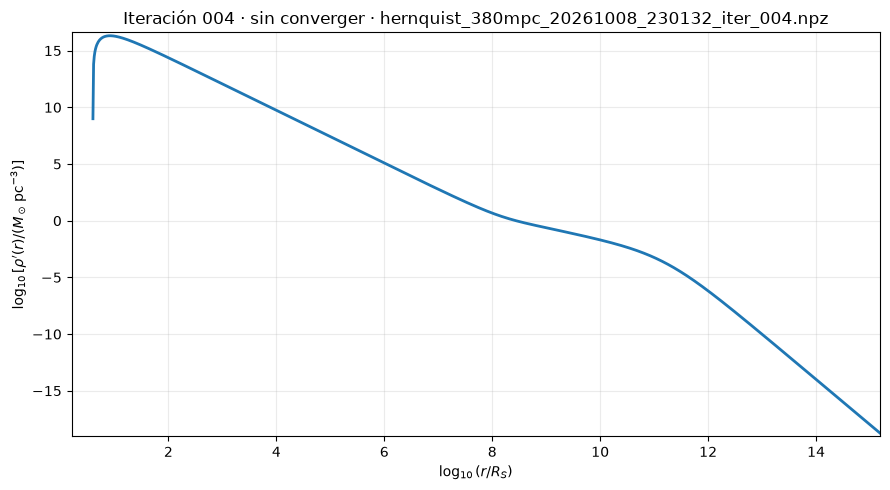

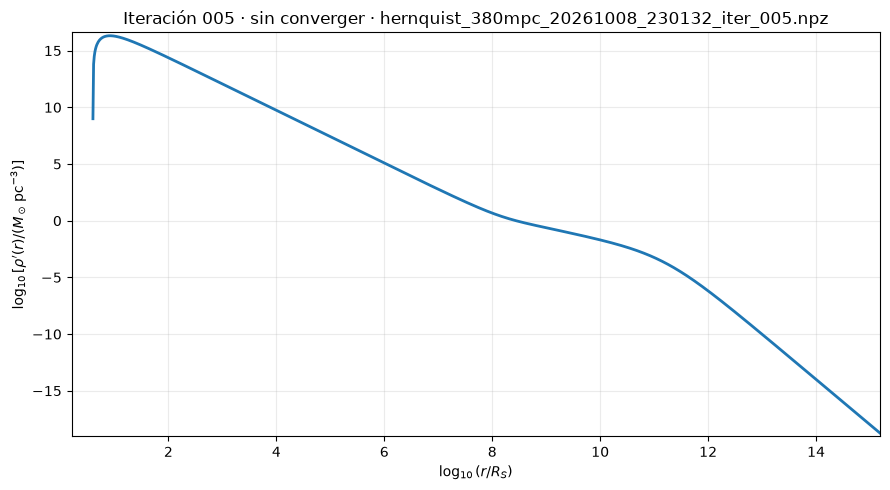

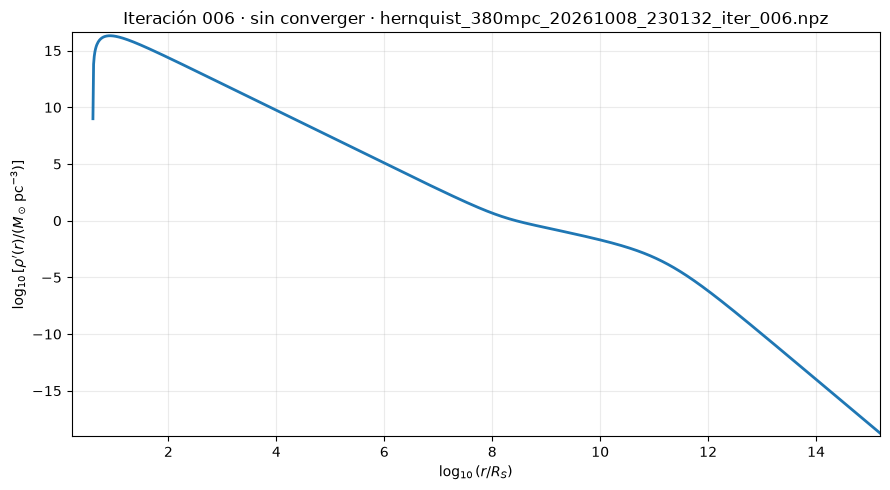

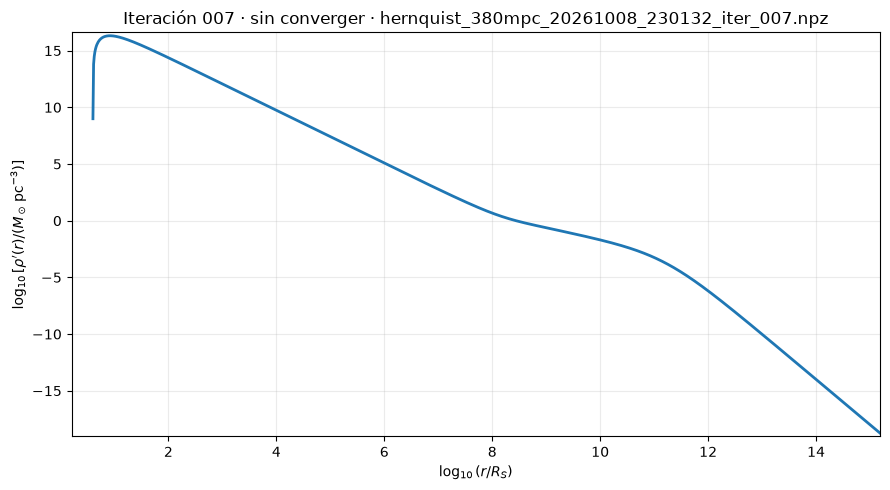

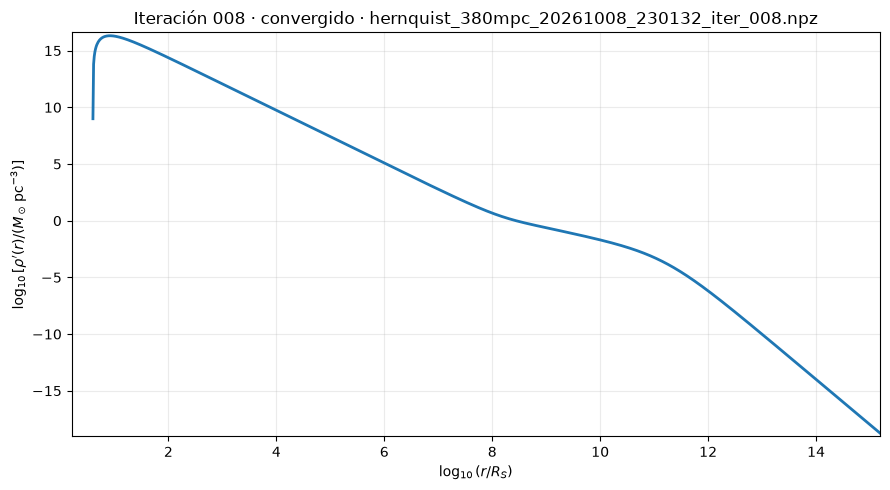

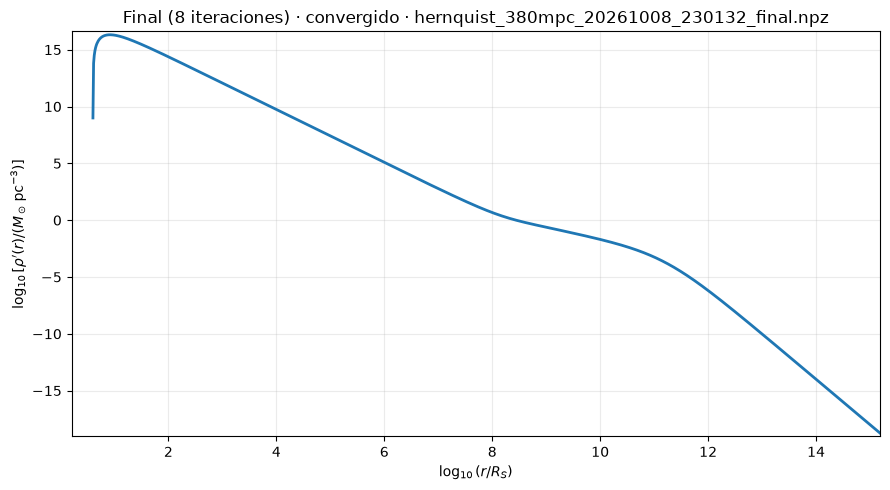

In [2]:
for rec in records:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']), linewidth=2)
    status = 'convergido' if rec['converged'] else 'sin converger'
    format_axes(ax, f"{rec['label']} · {status} · {rec['path'].name}")
    fig.tight_layout()
    plt.show()

## Todos los resultados superpuestos

El recuadro inferior izquierdo amplía $7.9\leq\log_{10}(r/R_S)\leq8$ con las mismas curvas y estilos que el gráfico principal.

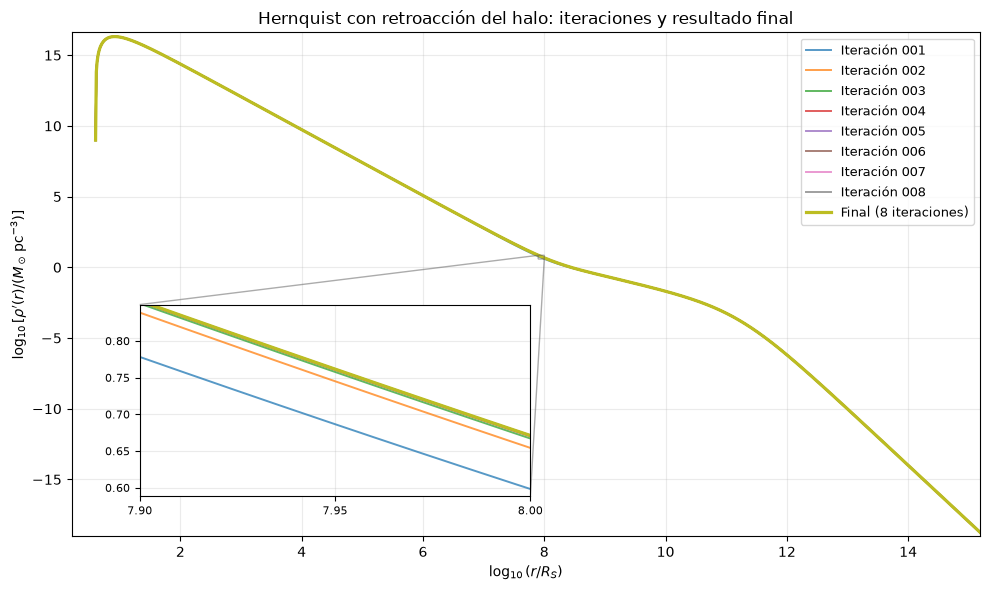

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for rec in records:
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']), label=rec['label'],
            linewidth=2.3 if rec['is_final'] else 1.4,
            alpha=1 if rec['is_final'] else 0.75)
format_axes(ax, 'Hernquist con retroacción del halo: iteraciones y resultado final')
add_profile_zoom(ax)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()

## Comparación con el perfil analítico final para $\gamma=1$

Se toman $M_{\rm halo}$ y $a$ de la configuración de los NPZ. El modelo inicial de Hernquist es

$$\rho_{\rm H}(r)=\frac{M_{\rm halo}a}{2\pi r(r+a)^3}.$$

Su comportamiento interior es $\rho_{\rm H}(r)\simeq M_{\rm halo}/(2\pi a^2r)$ para $r\ll a$. Por eso, la ley de potencia de comparación usa $\gamma=1$, $r_0=a$ y $\rho_0=M_{\rm halo}/(2\pi a^3)$: comparte el coeficiente interior del Hernquist. El spike analítico corresponde a esa ley de potencia inicial y se dibuja entre $4.0001R_S$ y su propio $R_{\rm sp}$; es una comparación aproximada para el halo Hernquist completo.

El recuadro inferior izquierdo amplía $7.9\leq\log_{10}(r/R_S)\leq8$ con las mismas curvas y estilos que el gráfico principal.

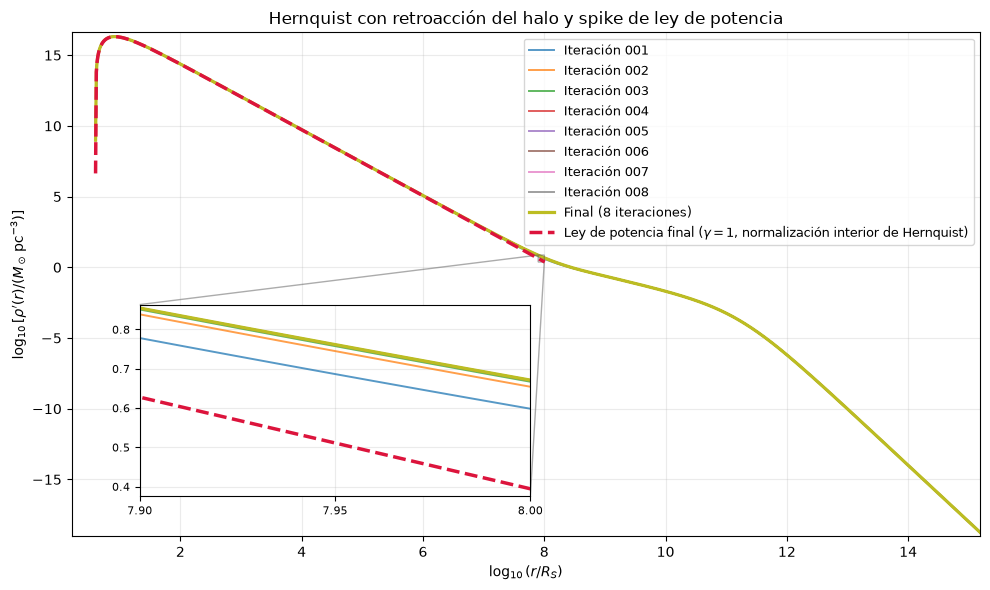

R_S = 2.48841e-07 pc; R_sp = 25.3212 pc; M_halo = 6.06e+11 Msun; a = 40000 pc (parámetros del NPZ); rho0 interior = 0.001507 Msun/pc³


In [4]:
for rec in records:
    config = rec['config']
    if (config['M_bh'] != reference['M_bh']
            or config['clight'] != reference['clight']
            or config['G'] != reference['G']
            or config['density'] != reference['density']):
        raise ValueError(f"Normalización distinta en {rec['path'].name}")

gamma = 1.0
M_bh = reference['M_bh']
# Misma masa y radio de escala que el cálculo numérico guardado.
M_halo = reference['density']['parameters']['total_mass']
a = reference['density']['parameters']['scale_radius']
rho0_inner = M_halo / (2.0 * np.pi * a**3)
r0_inner = a
R_sp = spike_radius(M_bh, gamma, rho0_inner, r0_inner)
r_power_law = np.geomspace(4.0001 * R_S, R_sp, 600)
rho_power_law = cusp_profile(r_power_law, M_bh, gamma, R_S,
                             r0=r0_inner, rho0=rho0_inner)

fig, ax = plt.subplots(figsize=(10, 6))
for rec in records:
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']),
            label=rec['label'], linewidth=2.3 if rec['is_final'] else 1.4,
            alpha=1 if rec['is_final'] else 0.75)
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law),
        color='crimson', linestyle='--', linewidth=2.5,
        label=r'Ley de potencia final ($\gamma=1$, normalización interior de Hernquist)',
        zorder=10)
format_axes(ax, 'Hernquist con retroacción del halo y spike de ley de potencia')
add_profile_zoom(ax)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()
print(f'R_S = {R_S:.6g} pc; R_sp = {R_sp:.6g} pc; '
      f'M_halo = {M_halo:g} Msun; a = {a:g} pc (parámetros del NPZ); '
      f'rho0 interior = {rho0_inner:.6g} Msun/pc³')

## Perfil convergido y pendiente logarítmica local

El panel superior representa la densidad en coordenadas logarítmicas. El inferior muestra $\gamma_{\mathrm{eff}}(r)=-d\ln\rho^\prime/d\ln r$, calculada por diferencias centradas en $\ln r$. Se omiten veinte puntos en cada extremo del panel de pendientes. La línea vertical discontinua marca $\log_{10}(R_{\rm sp}/R_S)$ para la ley de potencia de $\gamma=1$ calculada con spike_radius.

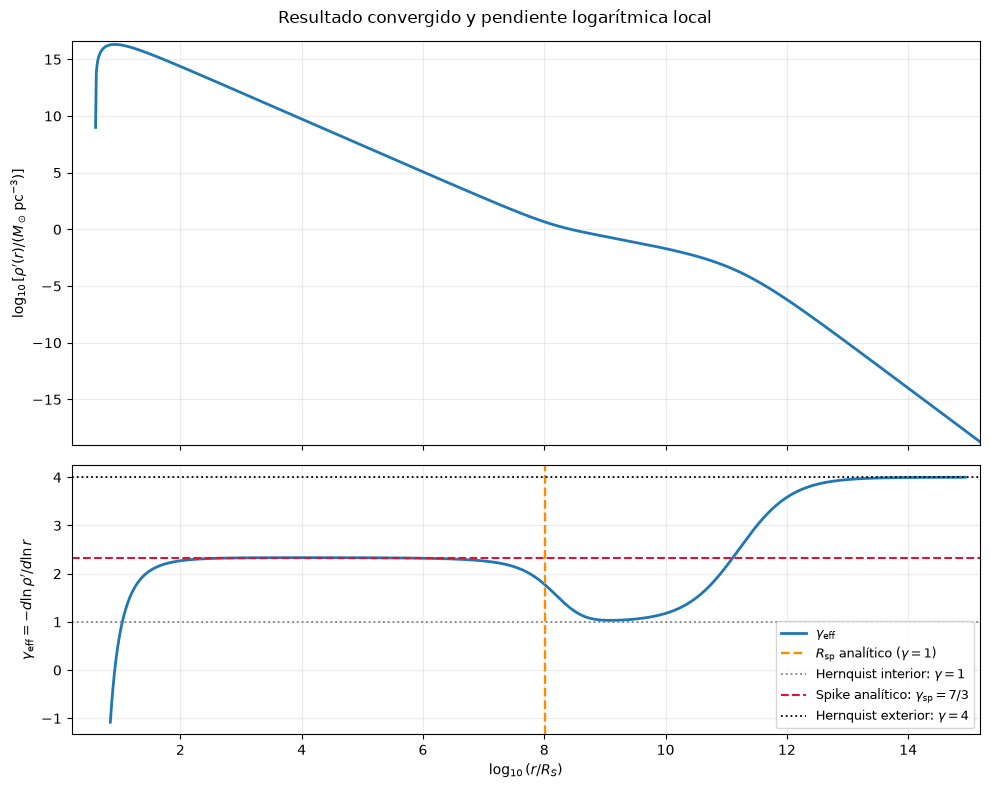

In [5]:
converged_record = next(rec for rec in records if rec['is_final'] and rec['converged'])
r_converged = converged_record['radii']
rho_converged = converged_record['density']
x_converged = np.log10(r_converged / R_S)
y_converged = np.log10(rho_converged)
gamma_eff = -np.gradient(np.log(rho_converged), np.log(r_converged))

trim = 20
fig, (ax_profile, ax_slope) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 2]}
)
ax_profile.plot(x_converged, y_converged, color='tab:blue', linewidth=2)
ax_profile.set_ylabel(r'$\log_{10}[\rho^\prime(r)/(M_\odot\,\mathrm{pc}^{-3})]$')
ax_profile.set_ylim(np.log10(rho_min / 2), np.log10(rho_max * 2))
ax_profile.grid(True, alpha=0.25)

ax_slope.plot(x_converged[trim:-trim], gamma_eff[trim:-trim],
              color='tab:blue', linewidth=2, label=r'$\gamma_{\mathrm{eff}}$')
ax_slope.axvline(np.log10(R_sp / R_S), color='darkorange',
                 linestyle='--', linewidth=1.7,
                 label=r'$R_{\rm sp}$ analítico ($\gamma=1$)')
ax_slope.axhline(1.0, color='gray', linestyle=':', linewidth=1.3,
                 label=r'Hernquist interior: $\gamma=1$')
ax_slope.axhline(gamma_spike(1.0), color='crimson', linestyle='--',
                 linewidth=1.5, label=r'Spike analítico: $\gamma_{\rm sp}=7/3$')
ax_slope.axhline(4.0, color='black', linestyle=':', linewidth=1.3,
                 label=r'Hernquist exterior: $\gamma=4$')
ax_slope.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
             xlabel=r'$\log_{10}(r/R_S)$',
             ylabel=r'$\gamma_{\mathrm{eff}}=-d\ln\rho^\prime/d\ln r$')
ax_slope.grid(True, alpha=0.25)
ax_slope.legend(loc='best', fontsize=9)
fig.suptitle('Resultado convergido y pendiente logarítmica local')
fig.tight_layout()
plt.show()

## Cambio relativo entre iteraciones consecutivas

Para cada iteración $k=1,\ldots,8$ guardada en `results/HRNQ_380Mpc_1200_results`, se representa $|\rho_k^\prime(r)-\rho_{k-1}^\prime(r)|/\rho_{k-1}^\prime(r)$. La iteración $k=0$ es el perfil inicial calculado con los parámetros de `config_json`. El archivo final reproduce la última iteración y no se cuenta dos veces. La escala vertical `symlog` permite apreciar los cambios de varios órdenes de magnitud. La línea horizontal discontinua marca la tolerancia relativa de convergencia $10^{-4}$, aplicada al máximo del cambio sobre todos los radios.

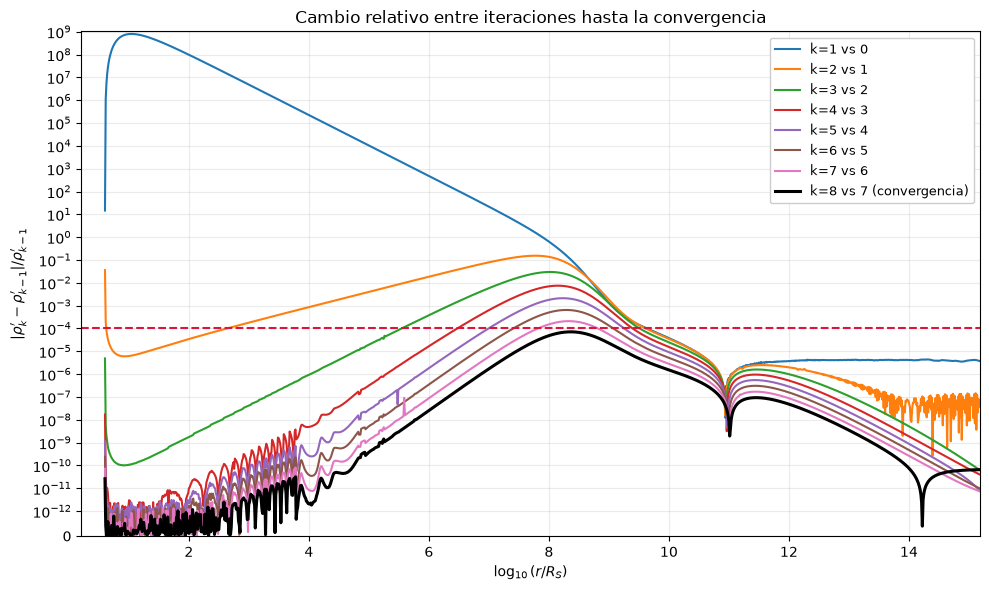

In [6]:
iteration_records = sorted(
    (rec for rec in records if not rec['is_final']),
    key=lambda rec: rec['iteration'],
)
if not iteration_records or [rec['iteration'] for rec in iteration_records] != list(
    range(1, converged_record['iteration'] + 1)
):
    raise ValueError('Faltan iteraciones para calcular cambios consecutivos hasta la convergencia.')
if not iteration_records[-1]['converged']:
    raise ValueError('La última iteración guardada no figura como convergida.')
if not np.allclose(iteration_records[-1]['density'], rho_converged, rtol=1e-12, atol=0):
    raise ValueError('El resultado final difiere de la última iteración guardada.')

initial_density = hernquist(**reference['density']['parameters'])(iteration_records[0]['radii'])
previous_density = initial_density  # k=0: perfil analítico inicial usado por el solver.
max_error = 0.0
fig, ax = plt.subplots(figsize=(10, 6))
for rec in iteration_records:
    if not np.array_equal(rec['radii'], iteration_records[0]['radii']):
        raise ValueError(f"Malla radial distinta en {rec['path'].name}")
    if not np.all(np.isfinite(previous_density)) or np.any(previous_density <= 0):
        raise ValueError('La densidad anterior debe ser positiva y finita.')
    k = rec['iteration']
    relative_change = np.abs(rec['density'] / previous_density - 1.0)
    max_error = max(max_error, float(np.max(relative_change)))
    is_last = k == iteration_records[-1]['iteration']
    ax.plot(np.log10(rec['radii'] / R_S), relative_change,
            color='black' if is_last else None,
            linewidth=2.2 if is_last else 1.5,
            label=f'k={k} vs {k - 1}' + (' (convergencia)' if is_last else ''))
    previous_density = rec['density']

ax.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
       ylim=(0, max_error * 1.3),
       xlabel=r'$\log_{10}(r/R_S)$',
       ylabel=r'$|\rho_k^\prime-\rho_{k-1}^\prime|/\rho_{k-1}^\prime$',
       title='Cambio relativo entre iteraciones hasta la convergencia')
ax.set_yscale('symlog', linthresh=1e-12)
ax.axhline(reference['solver']['rtol'], color='crimson', linestyle='--', linewidth=1.5)
ax.grid(True, alpha=0.25)
ax.legend(loc='upper right', fontsize=9, framealpha=1.0)
fig.tight_layout()
plt.show()


## Resultado convergido y perfiles iniciales y finales

El Hernquist inicial se evalúa con la expresión $\rho_{\rm H}(r)=M_{\rm halo}a/[2\pi r(r+a)^3]$ y los parámetros guardados en los NPZ. Así, el perfil inicial y el convergido corresponden al mismo halo.

Las leyes de potencia inicial y final usan $\gamma=1$, $\rho_0=M_{\rm halo}/(2\pi a^3)$ y $r_0=a$, y llegan a $R_{\rm sp}$. La ley de potencia inicial aproxima el Hernquist en la región $r\ll a$ y aparece con cruces verdes sin línea.


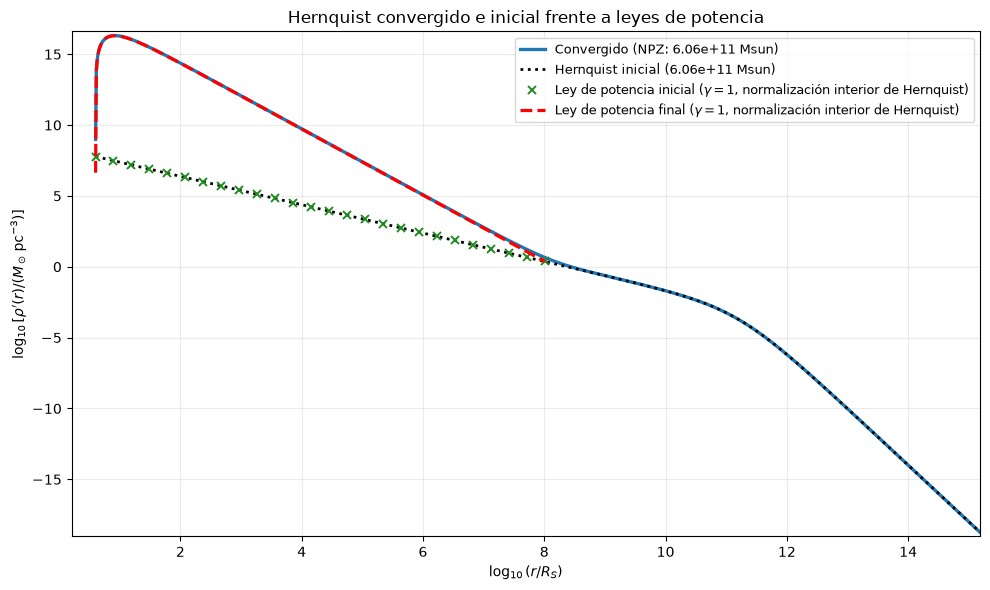

In [7]:
rho_hernquist_initial = hernquist(**reference['density']['parameters'])(r_converged)
rho_power_law_initial = power_law(
    rho0=rho0_inner, r0=r0_inner, gamma=gamma
)(r_power_law)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_converged, y_converged, color='tab:blue', linewidth=2.4,
        label=f'Convergido (NPZ: {M_halo:.2e} Msun)')
ax.plot(x_converged, np.log10(rho_hernquist_initial), color='black',
        linestyle=':', linewidth=2.0,
        label=f'Hernquist inicial ({M_halo:.2e} Msun)')
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law_initial),
        color='forestgreen', linestyle='None', marker='x', markersize=6,
        markeredgewidth=1.4,
        markevery=np.linspace(0, len(r_power_law) - 1, 26, dtype=int),
        label=r'Ley de potencia inicial ($\gamma=1$, normalización interior de Hernquist)')
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law),
        color='red', linestyle='--', linewidth=2.3,
        label=r'Ley de potencia final ($\gamma=1$, normalización interior de Hernquist)')

format_axes(ax, 'Hernquist convergido e inicial frente a leyes de potencia')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()

In [8]:
# Masa de materia oscura en el dominio tabulado: 4*pi*integral(s**2*rho ds).
# Regla del trapecio sobre los mismos radios para ambos perfiles; sin dm_spikes.
s = np.asarray(converged_record['radii'], dtype=float)
rho_f = np.asarray(converged_record['density'], dtype=float)
parameters = converged_record['config']['density']['parameters']
M_halo_mass = parameters['total_mass']
a_mass = parameters['scale_radius']
rho_i = M_halo_mass * a_mass / (2.0 * np.pi * s * (s + a_mass)**3)

ds = np.diff(s)
integrand_f = 4.0 * np.pi * s**2 * rho_f
integrand_i = 4.0 * np.pi * s**2 * rho_i
M_f = np.sum(0.5 * (integrand_f[:-1] + integrand_f[1:]) * ds)
M_i = np.sum(0.5 * (integrand_i[:-1] + integrand_i[1:]) * ds)

print(f'Dominio: [{s[0]:.8g}, {s[-1]:.8g}] pc')
print(f'Masa final en el dominio:   {M_f:.8e} Msun')
print(f'Masa inicial en el dominio: {M_i:.8e} Msun')
print(f'Mf/Mi en porcentaje: {100.0 * M_f / M_i:.6f} %')


Dominio: [9.9561365e-07, 3.8e+08] pc
Masa final en el dominio:   6.05951565e+11 Msun
Masa inicial en el dominio: 6.05951595e+11 Msun
Mf/Mi en porcentaje: 99.999995 %


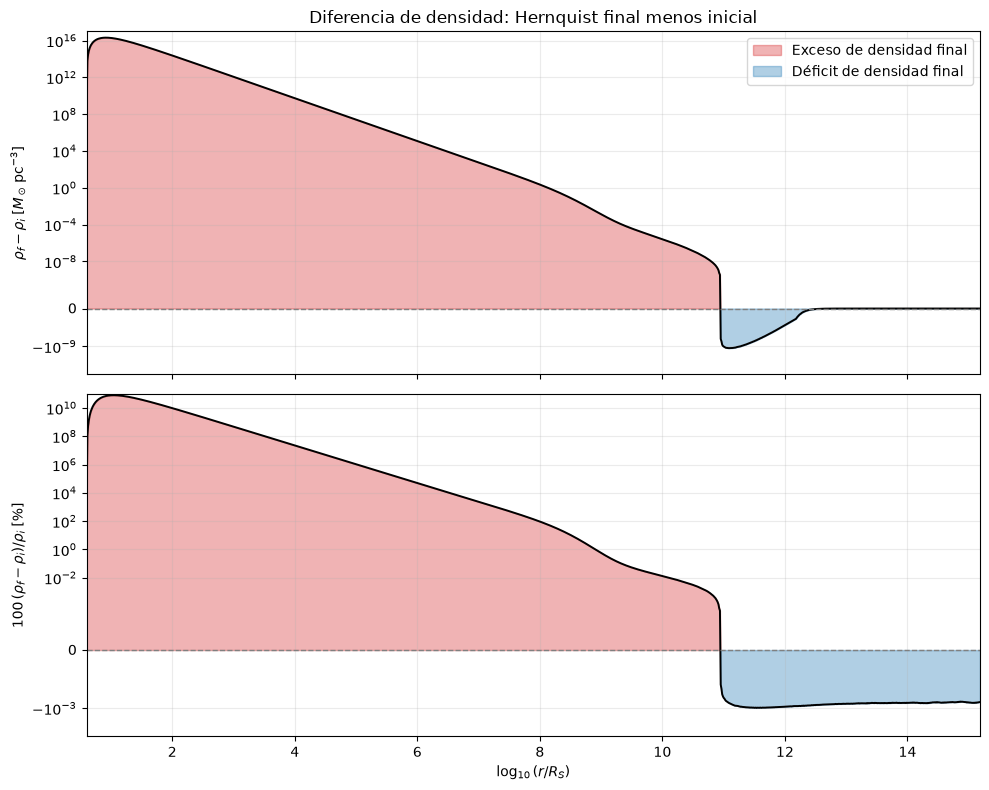

In [9]:
# Diferencia con signo entre el perfil final y el Hernquist inicial.
# Usa s, rho_f y rho_i de la celda de masa anterior.
delta_rho = rho_f - rho_i
delta_rho_percent = 100.0 * delta_rho / rho_i
x_difference = np.log10(s / R_S)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Unas pocas marcas por décadas evitan que la escala simétrica se amontone en cero.
for ax, difference, threshold, yticks, ylabel in (
    (axes[0], delta_rho, 1e-12,
     [-1e-9, 0, 1e-8, 1e-4, 1, 1e4, 1e8, 1e12, 1e16],
     r'$\rho_f-\rho_i\;[M_\odot\,\mathrm{pc}^{-3}]$'),
    (axes[1], delta_rho_percent, 1e-6,
     [-1e-3, 0, 1e-2, 1, 1e2, 1e4, 1e6, 1e8, 1e10],
     r'$100\,(\rho_f-\rho_i)/\rho_i\;[\%]$'),
):
    ax.plot(x_difference, difference, color='black', linewidth=1.4)
    ax.fill_between(x_difference, 0, difference, where=difference > 0,
                    interpolate=True, color='tab:red', alpha=0.35,
                    label='Exceso de densidad final')
    ax.fill_between(x_difference, 0, difference, where=difference < 0,
                    interpolate=True, color='tab:blue', alpha=0.35,
                    label='Déficit de densidad final')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    # symlog conserva los signos y el cero; el entorno de cero es lineal.
    ax.set_yscale('symlog', linthresh=threshold)
    lower = -(10.0 ** (np.ceil(np.log10(-np.min(difference))) + 2))
    upper = 10.0 ** np.ceil(np.log10(np.max(difference)))
    ax.set_ylim(lower, upper)
    ax.set_yticks(yticks)
    ax.minorticks_off()
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)

axes[0].set_title('Diferencia de densidad: Hernquist final menos inicial')
axes[0].legend(loc='best')
axes[1].set_xlabel(r'$\log_{10}(r/R_S)$')
axes[1].set_xlim(x_difference[0], x_difference[-1])
fig.tight_layout()
plt.show()


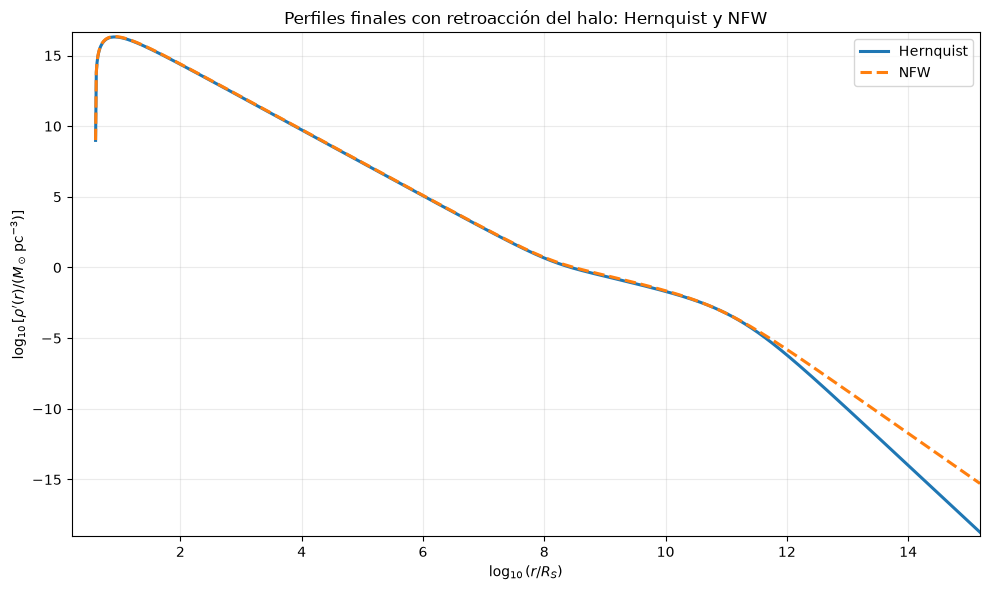

In [10]:
# Comparación de los perfiles convergidos de Hernquist y NFW.
nfw_path = ROOT / 'results' / 'NFW_test_1200' / 'nfw_380mpc.npz'
with np.load(nfw_path, allow_pickle=False) as data:
    r_nfw = np.asarray(data['radii'], dtype=float).copy()
    rho_nfw = np.asarray(data['rho_prime'], dtype=float).copy()
    config_nfw = json.loads(data['config_json'].item())
    nfw_converged = bool(data['converged'].item())
    nfw_radius_unit = data['radius_unit'].item()
    nfw_density_unit = data['density_unit'].item()

if not nfw_converged:
    raise ValueError(f'El resultado NFW no está convergido: {nfw_path.name}')
if (nfw_radius_unit, nfw_density_unit) != ('pc', 'Msun/pc^3'):
    raise ValueError('Las unidades del resultado NFW no son compatibles con Hernquist.')
if (config_nfw['M_bh'], config_nfw['clight']) != (reference['M_bh'], reference['clight']):
    raise ValueError('Los resultados usan masas de agujero negro o velocidades de la luz distintas.')
if not (np.all(np.isfinite(r_nfw)) and np.all(np.isfinite(rho_nfw))
        and np.all(r_nfw > 0) and np.all(rho_nfw > 0)):
    raise ValueError('El resultado NFW requiere radios y densidades finitos y positivos.')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_converged, y_converged, color='tab:blue', linewidth=2.2,
        label='Hernquist')
ax.plot(np.log10(r_nfw / R_S), np.log10(rho_nfw), color='tab:orange',
        linestyle='--', linewidth=2.2, label='NFW')
format_axes(ax, 'Perfiles finales con retroacción del halo: Hernquist y NFW')
ax.set_ylim(np.log10(min(rho_min, rho_nfw.min()) / 2),
            np.log10(max(rho_max, rho_nfw.max()) * 2))
ax.legend(loc='best')
fig.tight_layout()
plt.show()